# Exploring VAEs and MNIST handwriting data

## Introduction and Packages

In this notebook we test the numpy VAE implementation on the MNIST dataset. We require a few external libraries for visualization, data handling, and downstream tasks like clustering. You may find all the relevant packages in `conda_env.yml`.

## Loading the dataset

/opt/anaconda3/envs/numpy_VAE/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training data shape: (56000, 784)
Testing data shape: (14000, 784)


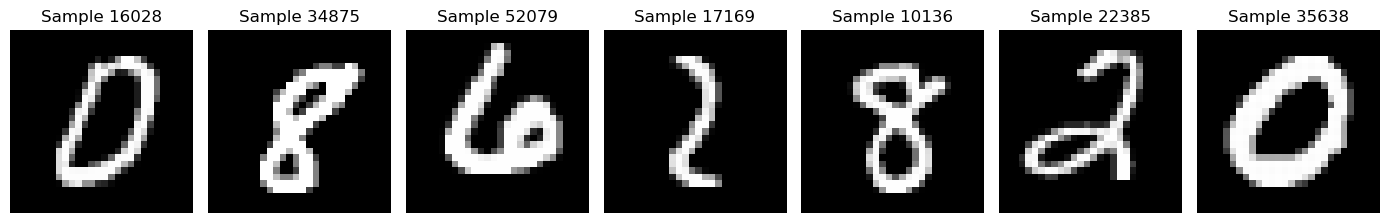

In [1]:
import numpy as np 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from src.utils import visualize_samples

#downloading MNIST dataset
print("Downloading MNIST...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X_full = mnist.data

# normalizing to (0,1)
X_full = X_full / 255

# train,test split
X_train, X_test = train_test_split(X_full, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}") 
print(f"Testing data shape: {X_test.shape}")

# checking out a few of the handwritten numbers
visualize_samples(X_train)

## Training VAE

We first initialize the VAE and adam optimizer. Feel free to play around with hyperparameters.

In [2]:
from src.model import VAE
from src.utils import AdamOptimizer

# hyperparam settings
hidden_dims = [512, 256]
latent_dims = 32
alpha = 1e-5

# initializing VAE
vae = VAE(input_dim = X_train.shape[1], hidden_dims = hidden_dims, latent_dim = latent_dims)
adam = AdamOptimizer(weights = vae.params, alpha = alpha)
print('Initialized VAE and ADAM optimzer')


Initialized VAE and ADAM optimzer


Let's see how well the VAE will reconstruct images without any training

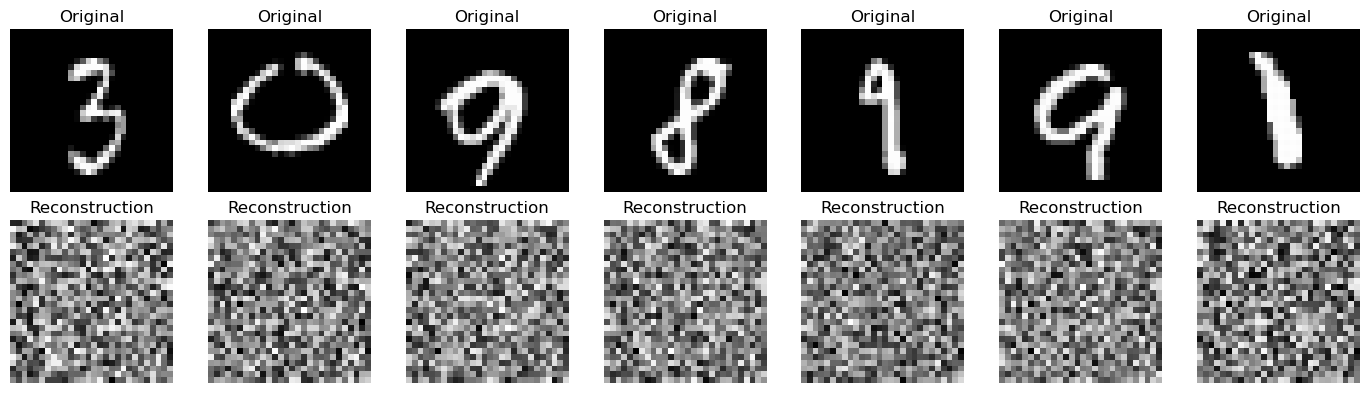

In [3]:
from src.utils import visualize_reconstruction

visualize_reconstruction(vae, X_train)

Let's now train for 5 epochs and see how well it is able to reconstruct images

In [ ]:
from src.train import train
from src.utils import visualize_loss

vae, epoch_loss = train(vae, adam, X_train, epochs = 5, batch_size = 128)

visualize_reconstruction(vae, X_train)

visualize_loss(epoch_loss)

Epoch 1/5 training...


Lets instead train with 25 epochs and see how it performs.

Epoch 1/25 training...
Epoch 1/25 completed in 11.86 seconds with mean loss 474.111
Epoch 2/25 training...
Epoch 2/25 completed in 11.61 seconds with mean loss 290.592
Epoch 3/25 training...
Epoch 3/25 completed in 11.41 seconds with mean loss 245.333
Epoch 4/25 training...
Epoch 4/25 completed in 12.72 seconds with mean loss 223.647
Epoch 5/25 training...
Epoch 5/25 completed in 11.81 seconds with mean loss 208.335
Epoch 6/25 training...
Epoch 6/25 completed in 11.43 seconds with mean loss 197.840
Epoch 7/25 training...
Epoch 7/25 completed in 11.85 seconds with mean loss 192.087
Epoch 8/25 training...
Epoch 8/25 completed in 11.59 seconds with mean loss 188.300
Epoch 9/25 training...
Epoch 9/25 completed in 11.59 seconds with mean loss 185.830
Epoch 10/25 training...
Epoch 10/25 completed in 13.06 seconds with mean loss 183.443
Epoch 11/25 training...
Epoch 11/25 completed in 12.65 seconds with mean loss 180.945
Epoch 12/25 training...
Epoch 12/25 completed in 12.45 seconds with mean

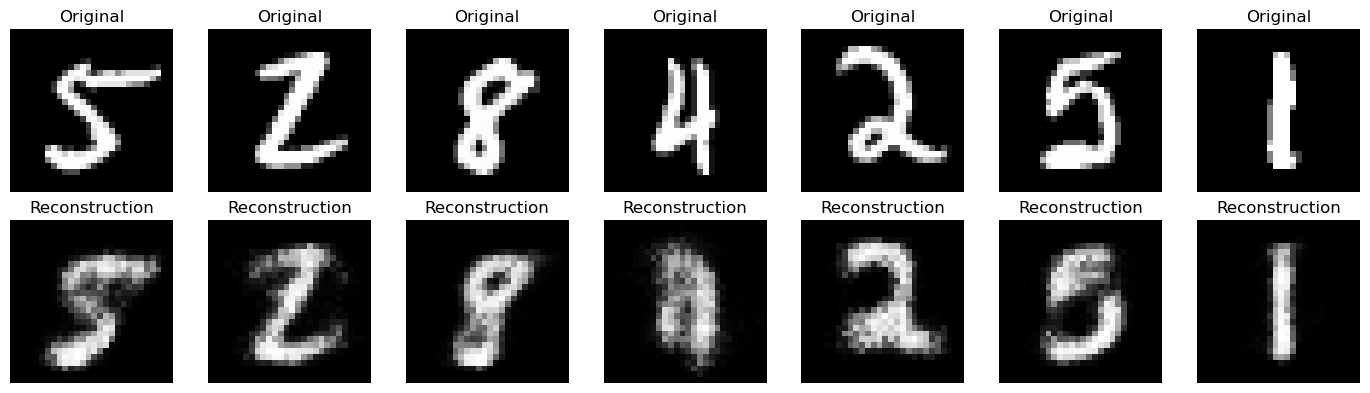

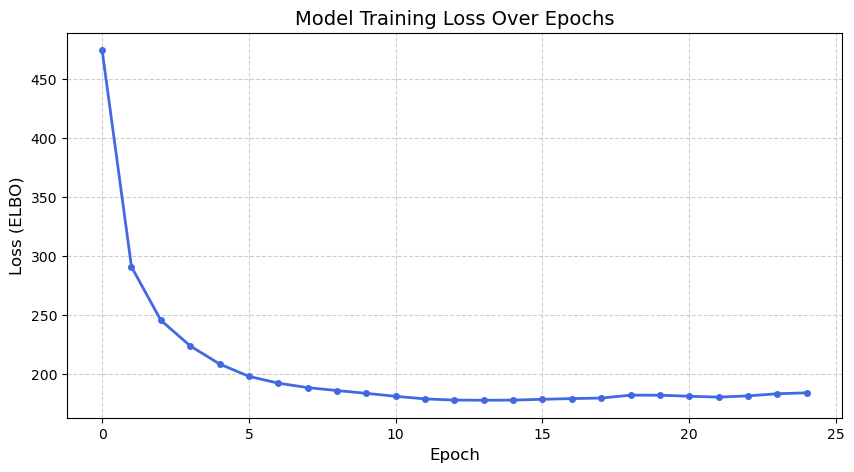

In [ ]:
vae = VAE(input_dim = X_train.shape[1], hidden_dims = hidden_dims, latent_dim = latent_dims)
adam = AdamOptimizer(weights = vae.params, alpha = alpha)

vae, epoch_loss = train(vae, adam, X_train, epochs = 25, batch_size = 128, patience=3)

visualize_reconstruction(vae, X_train)

visualize_loss(epoch_loss)

Finally, lets test it on the witheld test data.

The test loss is 183.804


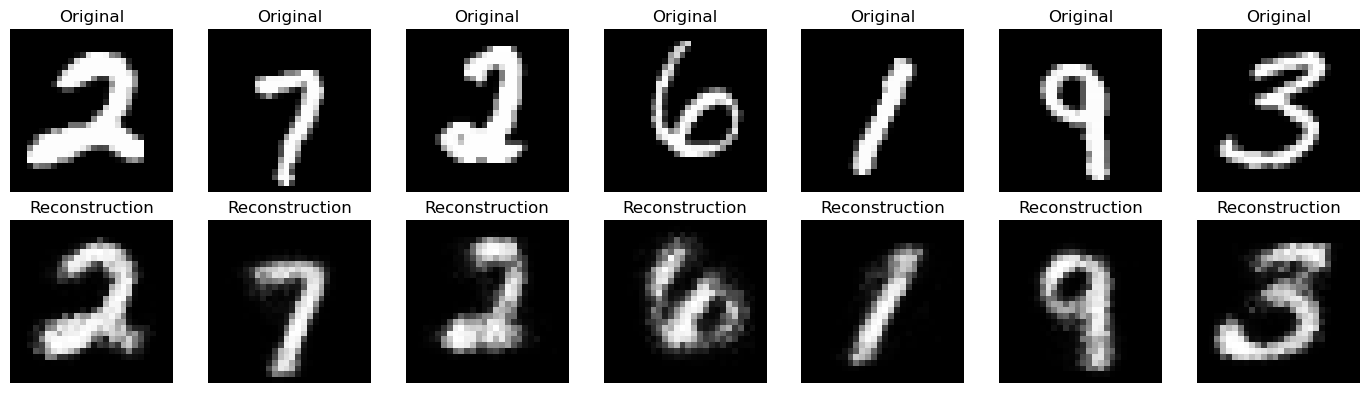

In [ ]:
_, loss = vae.full_pass(X_test)

print(f'The test loss is {loss:.3f}')

visualize_reconstruction(vae, X_test)

## Connections to Single Cell data

Now, lets see why VAEs like scVI are very helpful for analyzing single cell data.

Imagine, instead of passing flattened black and white images through the VAE, our data were gene expression vectors. Obviously, its pretty easy to display the image and visually identify what type the number is. For a gene expression vector, which have thousands of entries, you cannot inspect it. There will also be significantly more noise involved.

To determine cell types, we will use the latent representation of the data. This ought to be viewed as a compressed and denoised form of gene expression data, in which we extract from the gene expression whatever determines cell type. Mathematically, this aligns with the model as the latent variable $z$ encodes the cell type, while $p_\theta(x|z)$ is the actual, much noisier, gene expression.

Typically we run KNN, Leiden clustering, and a non-linear projection of the clustered latent space onto two dimensions to visualize each cell type. In theory, this allows us to identify, different cell types.

Let's see how this method carries over in the context of hand written numbers. First, we cluster the latent representation.

/opt/anaconda3/envs/numpy_VAE/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


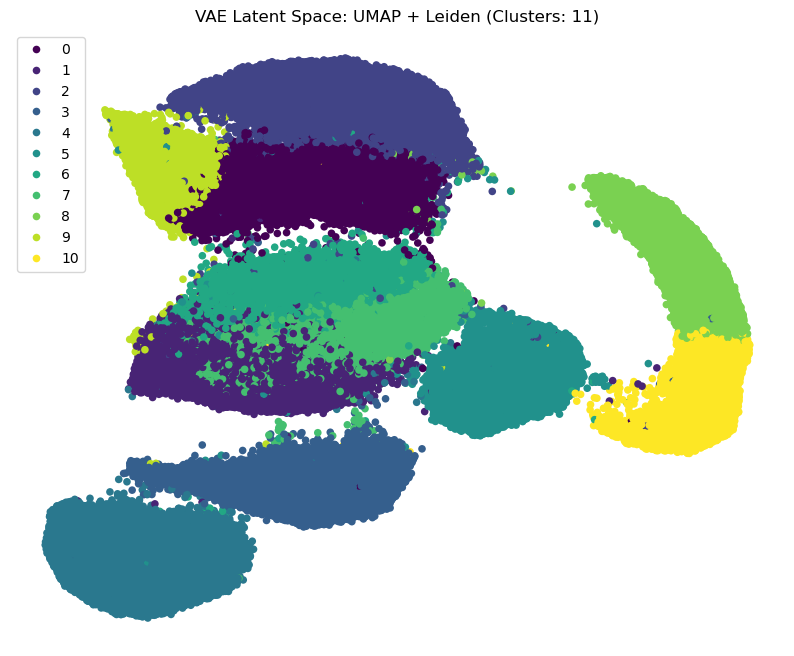

In [ ]:
from src.utils import clustering

# encoding all the data
mu, lv = vae.encode(X_test)

# latent clustering
embeddings, clusters = clustering(mu)

Now, lets compare the original and reconstructed images from the latent representation. We will do two for each cluster.

In [ ]:
from src.utils import cluster_reconstruction

cluster_reconstruction(vae, X_test)

ValueError: Found array with dim 3, while dim <= 2 is required.